# **Project Name**    -



##### **Project Type**    - CLustering
##### **Contribution**    - Individual


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
df = pd.read_csv("listings.csv", low_memory=False)

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
0,670339032744709144,Westwood lovely three bedrooms three bathrooms,4780152,Moon,20/01/13,within a few hours,0.96,f,West Los Angeles,City of Los Angeles,...,3.0,3.0,3.0,399.0,30,365,0,NaN,NaN,f
1,37014494,Spanish style lower duplex near Beverly Hills,278288178,Ida,22/07/19,NaN,NaN,f,Beverlywood,City of Los Angeles,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
2,1024835174766068422,Charming Beverly Hills Home,513813179,Tiana,08/05/23,within a day,0.60,f,Beverly Hills,Other Cities,...,3.0,3.0,3.0,434.0,30,267,0,NaN,NaN,f
3,850744632375448560,Tianpu's warm room with bathroom,432956623,Dan,22/11/21,a few days or more,0.20,f,Temple City,Other Cities,...,1.0,1.0,1.0,49.0,1,364,1,3.00,NaN,f
4,953950676345326970,"Santa Monica apt, free parking, steps to the b...",528669205,Farkhat,29/07/23,within an hour,1.00,t,Santa Monica,Other Cities,...,1.0,0.0,1.0,231.0,5,193,44,4.93,Exempt,t


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45533
Number of columns: 25


### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45533 entries, 0 to 45532
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            45533 non-null  int64  
 1   name                          45532 non-null  str    
 2   host_id                       45533 non-null  int64  
 3   host_name                     45531 non-null  str    
 4   host_since                    45531 non-null  str    
 5   host_response_time            35445 non-null  str    
 6   host_response_rate            35445 non-null  float64
 7   host_is_superhost             44281 non-null  str    
 8   neighbourhood_cleansed        45533 non-null  str    
 9   neighbourhood_group_cleansed  45533 non-null  str    
 10  latitude                      45533 non-null  float64
 11  longitude                     45533 non-null  float64
 12  property_type                 45533 non-null  str    
 13  room_type   

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()

id                                  0
name                                1
host_id                             0
host_name                           2
host_since                          2
host_response_time              10088
host_response_rate              10088
host_is_superhost                1252
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                        8239
bedrooms                         3039
beds                             8334
price                            8237
minimum_nights                      0
availability_365                    0
number_of_reviews                   0
review_scores_rating            12146
license                         32730
instant_bookable                    0
dtype: int64

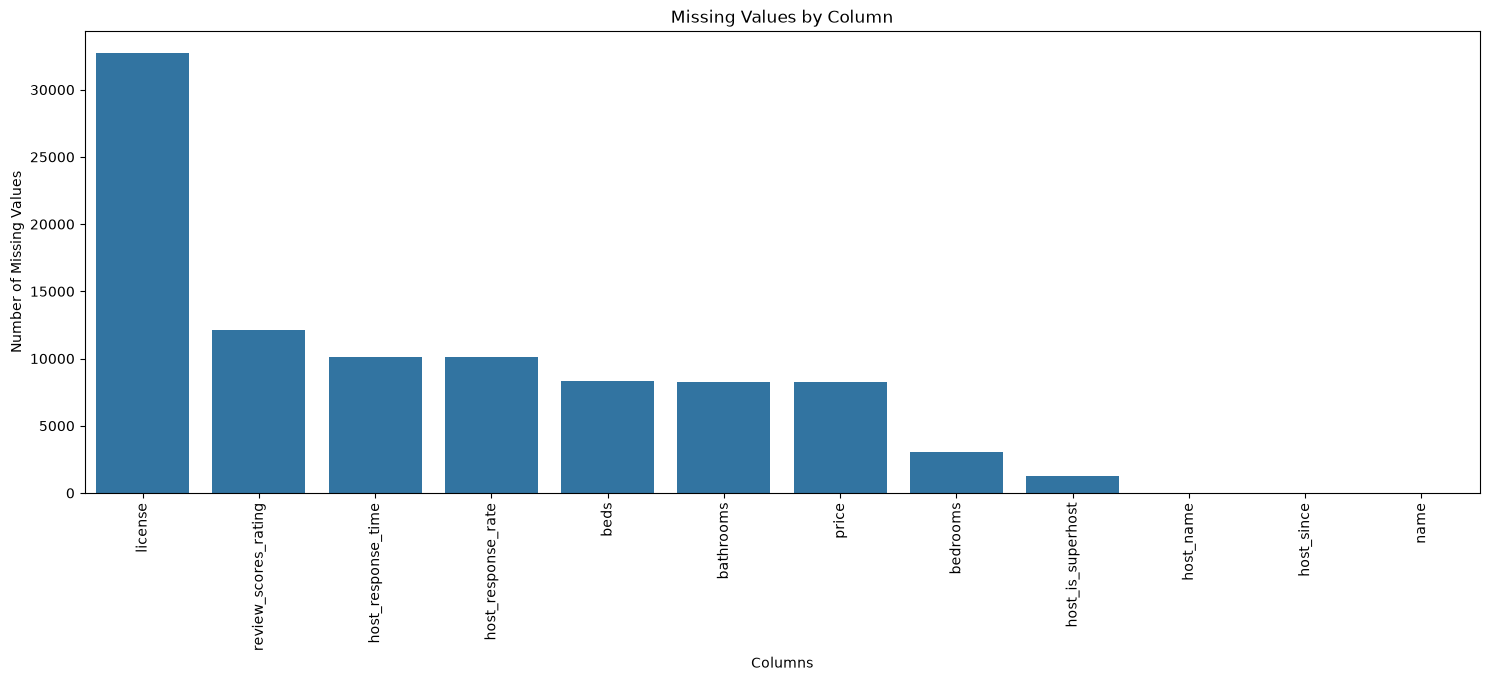

In [9]:
# Visualizing the missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(18,6))
sns.barplot(x=missing.index, y=missing.values)
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.show()

### What did you know about your dataset?

### Observations

- The dataset contains **45,533 rows** and **25 columns**.
- There are **no duplicate records**.
- It includes both **numerical** and **categorical** features.
- Several columns contain missing values, with **`license`** having the highest number of missing values.
- Important features such as **`price`**, **`bathrooms`**, **`beds`**, and **`review_scores_rating`** also contain missing values.
- Features like **`latitude`**, **`longitude`**, **`property_type`**, and **`room_type`** have no missing values and will be useful for clustering.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'host_since',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'license',
       'instant_bookable'],
      dtype='str')

In [11]:
# Dataset Describe
df.describe()

,id,host_id,host_response_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating
count,4.553300e+04,4.553300e+04,35445.000000,45533.000000,45533.000000,45533.000000,37294.000000,42494.000000,37199.000000,37296.000000,45533.000000,45533.000000,45533.000000,33387.000000
mean,5.208941e+17,1.950473e+08,0.952010,34.055308,-118.312743,4.019876,1.649434,1.786817,2.255786,289.377762,17.858520,195.093449,36.658929,4.778747
std,4.976570e+17,1.899825e+08,0.168667,0.141394,0.172210,2.861610,1.218398,1.339151,1.811313,715.366985,28.836101,133.394403,80.548528,0.415048
min,1.090000e+02,5.210000e+02,0.000000,33.338360,-118.917134,1.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,3.319485e+07,2.632699e+07,1.000000,33.998590,-118.413090,2.000000,1.000000,1.000000,1.000000,98.000000,2.000000,75.000000,0.000000,4.730000
50%,6.363561e+17,1.165631e+08,1.000000,34.060625,-118.343391,3.000000,1.000000,1.000000,2.000000,155.000000,14.000000,202.000000,6.000000,4.900000
75%,1.006571e+18,3.712316e+08,1.000000,34.108160,-118.233737,6.000000,2.000000,2.000000,3.000000,260.000000,30.000000,335.000000,34.000000,5.000000
max,1.238217e+18,5.997497e+08,1.000000,34.811183,-117.653352,16.000000,50.000000,50.000000,50.000000,56425.000000,1124.000000,365.000000,3024.000000,5.000000


### Variables Description

## Variable Description

- **id** : Unique identifier for each Airbnb listing.
- **name** : Title of the Airbnb listing.
- **host_id** : Unique identifier for the host.
- **host_name** : Name of the host.
- **host_since** : Date when the host joined Airbnb.
- **host_response_time** : Average response time of the host.
- **host_response_rate** : Percentage of inquiries responded to by the host.
- **host_is_superhost** : Indicates whether the host is a Superhost.
- **neighbourhood_cleansed** : Neighborhood where the listing is located.
- **neighbourhood_group_cleansed** : Broader neighborhood group of the listing.
- **latitude** : Latitude coordinate of the listing.
- **longitude** : Longitude coordinate of the listing.
- **property_type** : Type of property listed.
- **room_type** : Type of room offered.
- **accommodates** : Maximum number of guests the listing can accommodate.
- **bathrooms** : Number of bathrooms available.
- **bedrooms** : Number of bedrooms.
- **beds** : Number of beds available.
- **price** : Price per night of the listing.
- **minimum_nights** : Minimum number of nights required for booking.
- **availability_365** : Number of days the listing is available in a year.
- **number_of_reviews** : Total number of reviews received.
- **review_scores_rating** : Average guest rating of the listing.
- **license** : License or permit number of the listing.
- **instant_bookable** : Indicates whether the listing can be booked instantly.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
unique_values = pd.DataFrame({
    "Variable": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Variable,Unique Values
0,id,45533
1,name,44004
2,host_id,23202
3,host_name,8631
4,host_since,8692
5,host_response_time,4
6,host_response_rate,67
7,host_is_superhost,2
8,neighbourhood_cleansed,266
9,neighbourhood_group_cleansed,3


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.
df.drop(columns=[
    'id',
    'name',
    'host_id',
    'host_name'
], inplace=True)

df.head()

,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
0,20/01/13,within a few hours,0.96,f,West Los Angeles,City of Los Angeles,34.049660,-118.435550,Entire condo,Entire home/apt,...,3.0,3.0,3.0,399.0,30,365,0,NaN,NaN,f
1,22/07/19,NaN,NaN,f,Beverlywood,City of Los Angeles,34.048410,-118.387510,Entire rental unit,Entire home/apt,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
2,08/05/23,within a day,0.60,f,Beverly Hills,Other Cities,34.070583,-118.390742,Entire home,Entire home/apt,...,3.0,3.0,3.0,434.0,30,267,0,NaN,NaN,f
3,22/11/21,a few days or more,0.20,f,Temple City,Other Cities,34.109329,-118.073098,Private room in home,Private room,...,1.0,1.0,1.0,49.0,1,364,1,3.00,NaN,f
4,29/07/23,within an hour,1.00,t,Santa Monica,Other Cities,34.015590,-118.494080,Entire rental unit,Entire home/apt,...,1.0,0.0,1.0,231.0,5,193,44,4.93,Exempt,t


In [14]:
df.isnull().sum().sort_values(ascending=False)

license                         32730
review_scores_rating            12146
host_response_time              10088
host_response_rate              10088
beds                             8334
bathrooms                        8239
price                            8237
bedrooms                         3039
host_is_superhost                1252
host_since                          2
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
room_type                           0
accommodates                        0
longitude                           0
property_type                       0
availability_365                    0
minimum_nights                      0
number_of_reviews                   0
instant_bookable                    0
dtype: int64

In [15]:
df.drop(columns='license', inplace=True)


In [16]:
df[df['host_since'].str.contains(r'^\d+$', na=False)]

,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,instant_bookable
14561,41245,NaN,NaN,f,Sherman Oaks,City of Los Angeles,34.149140,-118.455810,Entire guesthouse,Entire home/apt,2,NaN,1.0,NaN,NaN,30,0,95,4.94,f
14562,41246,NaN,NaN,f,West Hollywood,Other Cities,34.091500,-118.373060,Entire rental unit,Entire home/apt,2,NaN,1.0,NaN,NaN,40,365,0,NaN,f
14563,40917,within an hour,1.00,t,Venice,City of Los Angeles,33.982123,-118.467784,Entire townhouse,Entire home/apt,6,2.5,2.0,2.0,343.0,1,279,54,4.98,f
14564,43895,within an hour,1.00,t,West Hollywood,Other Cities,34.093020,-118.346240,Entire rental unit,Entire home/apt,3,1.0,1.0,2.0,159.0,2,83,6,4.50,f
14565,44860,within an hour,1.00,f,Pico-Robertson,City of Los Angeles,34.058610,-118.383090,Entire rental unit,Entire home/apt,4,1.0,1.0,2.0,170.0,1,365,0,NaN,t
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45528,42748,NaN,NaN,f,Marina del Rey,Unincorporated Areas,33.976649,-118.457536,Entire rental unit,Entire home/apt,2,NaN,1.0,NaN,NaN,1,0,0,NaN,f
45529,45133,NaN,NaN,f,Downtown,City of Los Angeles,34.049102,-118.247411,Entire rental unit,Entire home/apt,3,NaN,NaN,NaN,NaN,30,89,0,NaN,f
45530,44855,within an hour,1.00,f,Long Beach,Other Cities,33.788520,-118.171780,Room in boutique hotel,Private room,5,NaN,2.0,NaN,NaN,31,244,0,NaN,t
45531,41498,within an hour,1.00,t,Jefferson Park,City of Los Angeles,34.027010,-118.326880,Entire home,Entire home/apt,2,1.0,0.0,1.0,116.0,2,141,212,4.84,t


In [17]:
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')

C:\Users\HP\AppData\Local\Temp\ipykernel_2732\2790791020.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')


In [18]:
df['host_since'].head(20)

0    2013-01-20
1    2019-07-22
2    2023-08-05
3    2021-11-22
4    2023-07-29
5    2024-01-22
6    2012-11-14
7    2023-04-19
8    2021-06-29
9    2022-01-11
10   2021-01-08
11   2019-02-25
12   2021-07-27
13   2016-06-30
14   2018-08-03
15   2014-07-04
16   2016-04-22
17   2023-02-22
18   2020-11-09
19   2022-11-24
Name: host_since, dtype: datetime64[us]

In [19]:
df['host_since'] = pd.to_datetime(
    df['host_since'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [20]:
df['host_since_year'] = df['host_since'].dt.year

In [21]:
df['host_since_year'] = df['host_since_year'].fillna(df['host_since_year'].median())

In [22]:
df.drop(columns='host_since', inplace=True)

In [23]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_2732\1384138331.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_2732\1384138331.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an 

In [24]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_2732\2422164989.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
C:\Users\HP\AppData\Local\Temp\ipykernel_2732\2422164989.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col]

In [25]:
df.isnull().sum()

host_response_time              10088
host_response_rate              10088
host_is_superhost                1252
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                        8239
bedrooms                         3039
beds                             8334
price                            8237
minimum_nights                      0
availability_365                    0
number_of_reviews                   0
review_scores_rating            12146
instant_bookable                    0
host_since_year                     0
dtype: int64

In [26]:
num_cols = [
    'host_response_rate',
    'bathrooms',
    'bedrooms',
    'beds',
    'price',
    'review_scores_rating'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [27]:
cat_cols = [
    'host_response_time',
    'host_is_superhost'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [28]:
df.isnull().sum()

host_response_time              0
host_response_rate              0
host_is_superhost               0
neighbourhood_cleansed          0
neighbourhood_group_cleansed    0
latitude                        0
longitude                       0
property_type                   0
room_type                       0
accommodates                    0
bathrooms                       0
bedrooms                        0
beds                            0
price                           0
minimum_nights                  0
availability_365                0
number_of_reviews               0
review_scores_rating            0
instant_bookable                0
host_since_year                 0
dtype: int64

### What all manipulations have you done and insights you found?

### Data Wrangling: Manipulations and Insights

#### Manipulations Performed
- Removed unnecessary columns such as **`id`**, **`name`**, **`host_id`**, and **`host_name`** as they do not contribute to clustering.
- Converted the **`host_since`** column into datetime format and extracted the **host joining year** (`host_since_year`).
- Dropped the original **`host_since`** column after feature extraction.
- Handled missing values by:
  - Filling **numerical features** with their **median** values.
  - Filling **categorical features** with their **mode** values.
- Verified that the dataset contains **no missing values** after preprocessing.

#### Insights
- The dataset initially contained missing values in several important features such as **`price`**, **`bathrooms`**, **`beds`**, and **`review_scores_rating`**.
- Identifier columns were removed since they do not provide meaningful information for clustering.
- Extracting the **host joining year** preserves temporal information while making it suitable for machine learning algorithms.
- The dataset is now clean and ready for **feature encoding**, **scaling**, and **clustering**.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

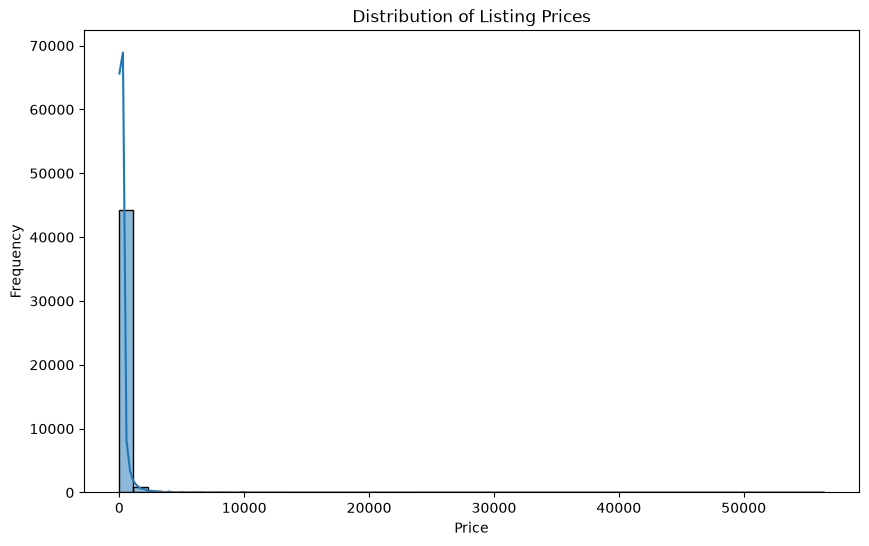

In [29]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Listing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to visualize the distribution of Airbnb listing prices. It helps identify the frequency of different price ranges, detect skewness, and reveal the presence of outliers, which are important for clustering analysis.


##### 2. What is/are the insight(s) found from the chart?

- Most Airbnb listings are concentrated in the lower price range.
- The distribution is highly **right-skewed**, indicating that only a few listings have very high prices.
- Several extreme price values (outliers) are present, which may influence clustering results.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the price distribution enables Airbnb to segment listings into different pricing categories, such as budget, mid-range, and luxury accommodations. These insights can support pricing strategies, improve customer recommendations, and help identify premium listings. Since significant outliers are present, appropriate preprocessing (such as scaling) will improve the performance of clustering algorithms.

#### Chart - 2

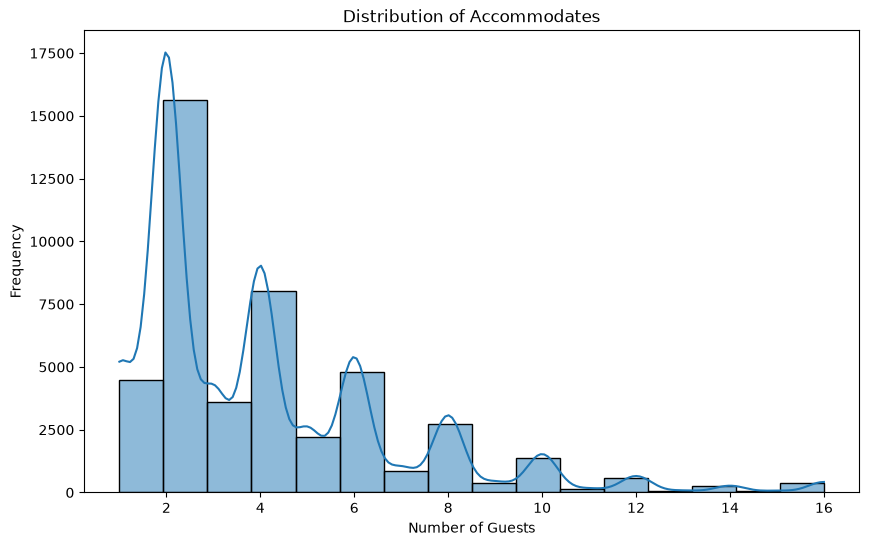

In [70]:
# Chart - 2 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df['accommodates'], bins=16, kde=True)

plt.title("Distribution of Accommodates")
plt.xlabel("Number of Guests")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to visualize the distribution of the **accommodates** feature. This helps understand the guest capacity of Airbnb listings and identify the most common accommodation sizes.


##### 2. What is/are the insight(s) found from the chart?

- Most Airbnb listings accommodate **2 to 4 guests**, indicating that smaller accommodations dominate the market.
- As the guest capacity increases beyond 6 people, the number of listings decreases significantly.
- Listings that accommodate **10 or more guests** are relatively uncommon, suggesting that large-group accommodations represent a smaller segment of the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart indicates that the majority of Airbnb listings are designed for small groups, couples, and families. This insight can help Airbnb improve recommendation systems, optimize pricing strategies, and focus marketing efforts on the most common accommodation sizes. The smaller number of large-capacity listings also highlights a niche market that hosts may explore to meet the needs of larger groups.

#### Chart - 3

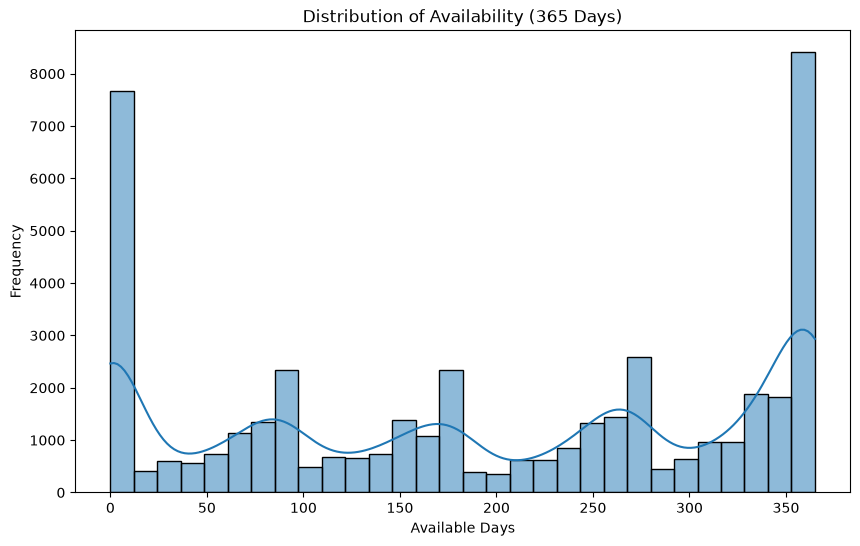

In [71]:
# Chart - 3 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df['availability_365'], bins=30, kde=True)

plt.title("Distribution of Availability (365 Days)")
plt.xlabel("Available Days")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to examine the distribution of the **availability_365** feature. It helps identify whether listings are available throughout the year or only for limited periods, which is an important characteristic for clustering.


##### 2. What is/are the insight(s) found from the chart?

- A large number of listings are available for **very few days (close to 0 days)**, indicating that many properties are either frequently booked or intentionally kept unavailable.
- Another significant group of listings is available for **almost the entire year (close to 365 days)**, suggesting that many hosts keep their properties open year-round.
- The distribution is **bimodal**, with clear peaks at both ends of the availability range, indicating two distinct hosting patterns rather than a single uniform trend.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The availability pattern helps Airbnb identify different types of hosts, such as full-time hosts who keep their listings available throughout the year and occasional hosts who rent out their properties for limited periods. These insights can improve customer recommendations, support targeted marketing strategies, and help optimize inventory management based on host availability.

#### Chart - 4

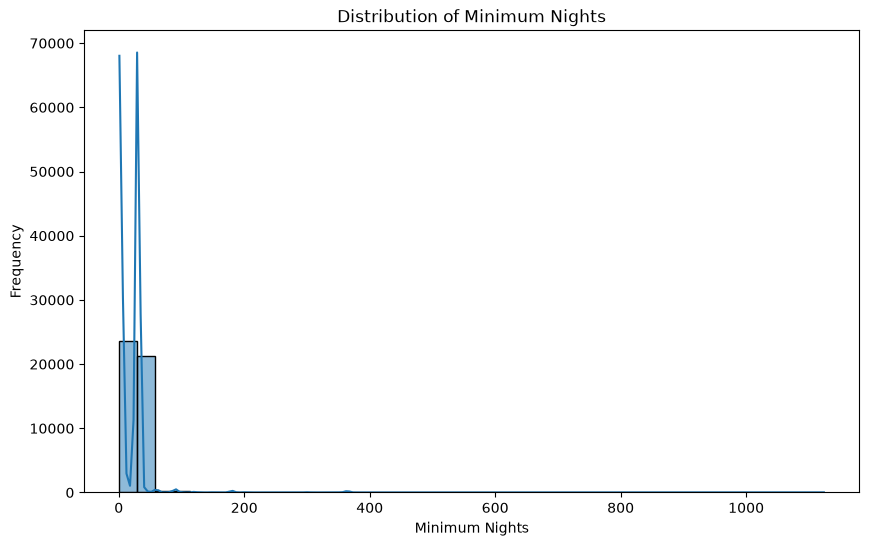

In [72]:
# Chart - 4 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df['minimum_nights'], bins=40, kde=True)

plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was chosen to examine the distribution of the **minimum_nights** feature. It helps identify common booking requirements and detect unusual booking policies or extreme values.


##### 2. What is/are the insight(s) found from the chart?

- Most Airbnb listings require a **small minimum stay**, indicating that short-term bookings are the most common.
- The distribution is **highly right-skewed**, with only a few listings requiring exceptionally long minimum stays.
- A small number of listings have extremely high minimum night requirements, suggesting the presence of outliers or long-term rental properties.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis shows that most listings are designed for short-term stays, which aligns with the preferences of many travelers. Identifying listings with unusually high minimum stay requirements can help Airbnb improve search filters, recommend suitable properties to different customer groups, and better segment listings during clustering.

#### Chart - 5

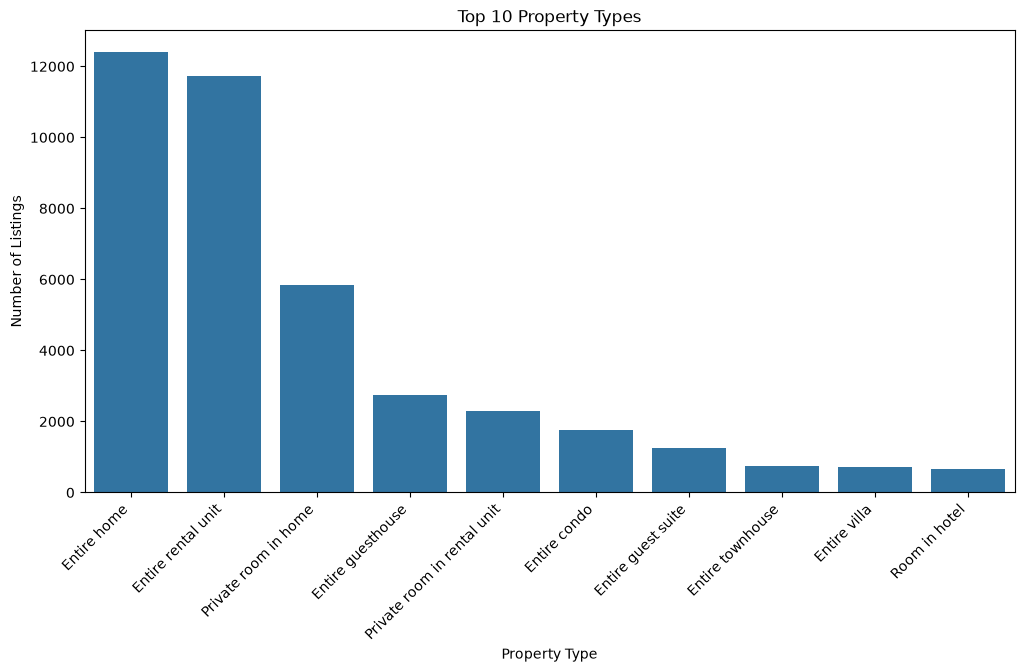

In [73]:
# Chart - 5 visualization code
plt.figure(figsize=(12,6))

top_property = df['property_type'].value_counts().head(10)

sns.barplot(
    x=top_property.index,
    y=top_property.values
)

plt.title("Top 10 Property Types")
plt.xlabel("Property Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha='right')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because **property_type** is a categorical feature. It provides a clear comparison of the most common property types and makes it easy to identify the dominant categories.


##### 2. What is/are the insight(s) found from the chart?

- **Entire homes** and **entire rental units** are the most common property types, indicating that guests generally prefer renting an entire place.
- **Private rooms in homes** are the third most common category but are significantly fewer than entire homes and rental units.
- Property types such as **townhouses**, **villas**, and **hotel rooms** have relatively few listings, suggesting they represent niche accommodation options.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis shows that entire properties dominate the Airbnb marketplace, indicating strong demand for private accommodations. These insights can help Airbnb optimize search recommendations, guide hosts on the types of properties with higher market presence, and support business decisions related to inventory expansion and targeted marketing for underrepresented property categories.

#### Chart - 6

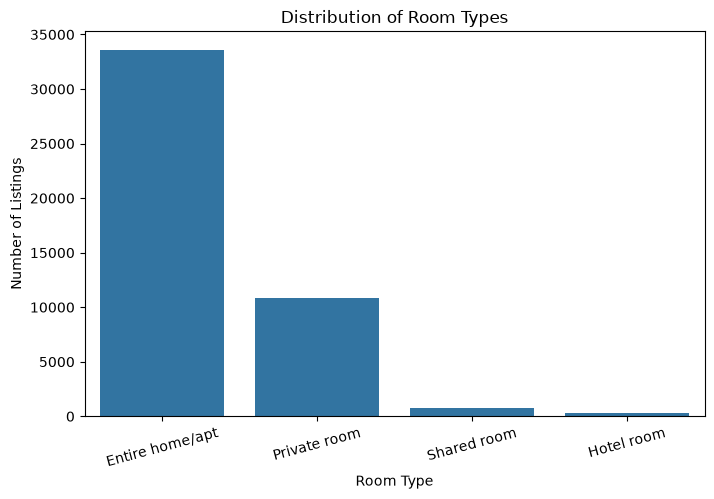

In [74]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))

sns.countplot(
    x='room_type',
    data=df,
    order=df['room_type'].value_counts().index
)

plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)

plt.show()

### 1. Why did you pick the specific chart?

A bar chart was chosen because **room_type** is a categorical feature. It provides a clear comparison of the number of listings available for each room type, making it easy to identify the most common accommodation options.

### 2. What is/are the insight(s) found from the chart?

- **Entire home/apartment** is the most common room type, accounting for the majority of Airbnb listings.
- **Private rooms** are the second most common option but are considerably fewer than entire homes/apartments.
- **Shared rooms** and **hotel rooms** represent only a small proportion of the listings, indicating lower availability and demand compared to other room types.

### 3. Will the gained insights help creating a positive business impact?

Yes. The analysis indicates that guests primarily prefer entire homes/apartments, while private rooms serve as an important secondary option. These insights can help Airbnb improve recommendation systems, optimize marketing strategies, and assist hosts in understanding the most competitive accommodation types within the marketplace.

#### Chart - 7

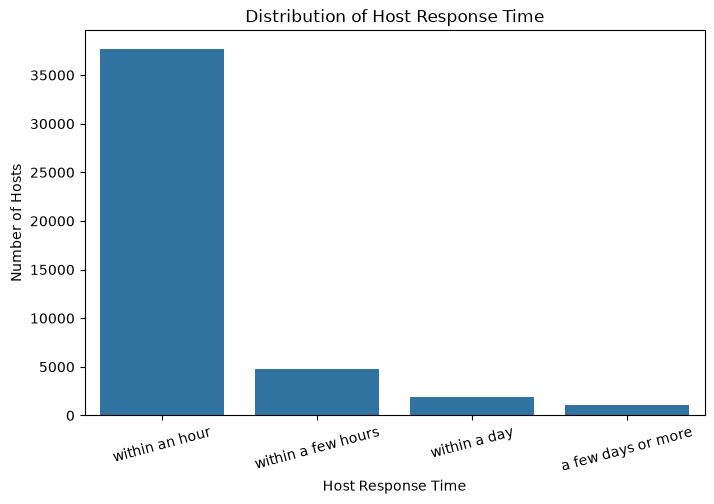

In [75]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))

sns.countplot(
    x='host_response_time',
    data=df,
    order=df['host_response_time'].value_counts().index
)

plt.title("Distribution of Host Response Time")
plt.xlabel("Host Response Time")
plt.ylabel("Number of Hosts")
plt.xticks(rotation=15)

plt.show()

### 1. Why did you pick the specific chart?

A bar chart was chosen because **host_response_time** is a categorical feature. It provides a clear comparison of the number of hosts in each response time category, making it easy to identify the most common response behavior.

### 2. What is/are the insight(s) found from the chart?

- The majority of hosts respond **within an hour**, indicating a high level of responsiveness on the platform.
- The number of hosts decreases as the response time increases, with **within a few hours**, **within a day**, and **a few days or more** being progressively less common.
- Fast response times appear to be the standard among Airbnb hosts, while delayed responses are relatively rare.

### 3. Will the gained insights help creating a positive business impact?

Yes. Fast host responses can improve guest satisfaction and increase the likelihood of successful bookings. These insights help Airbnb identify highly responsive hosts, enhance recommendation systems, and encourage slower-responding hosts to improve their response times, leading to a better overall customer experience.

#### Chart - 8

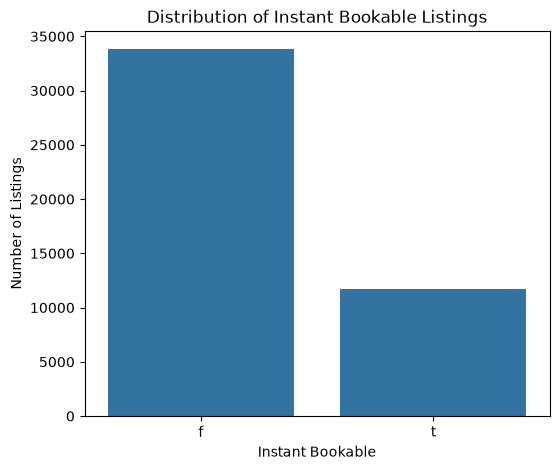

In [76]:
# Chart - 8 visualization code
plt.figure(figsize=(6,5))

sns.countplot(
    x='instant_bookable',
    data=df,
    order=df['instant_bookable'].value_counts().index
)

plt.title("Distribution of Instant Bookable Listings")
plt.xlabel("Instant Bookable")
plt.ylabel("Number of Listings")

plt.show()

### 1. Why did you pick the specific chart?

A bar chart was chosen because **instant_bookable** is a categorical feature. It provides a clear comparison between listings that can be booked instantly and those that require host approval.

### 2. What is/are the insight(s) found from the chart?

- The majority of Airbnb listings are **not instant bookable**, indicating that most hosts prefer to review booking requests before accepting them.
- Instant bookable listings represent a smaller proportion of the dataset.
- The noticeable difference between the two categories suggests that host approval remains the more common booking approach.

### 3. Will the gained insights help creating a positive business impact?

Yes. These insights help Airbnb understand host booking preferences and improve the booking experience for guests. Increasing the availability of instant bookable listings could reduce booking time, enhance customer satisfaction, and potentially increase booking conversions, while preserving host flexibility for those who prefer manual approval.

#### Chart - 9

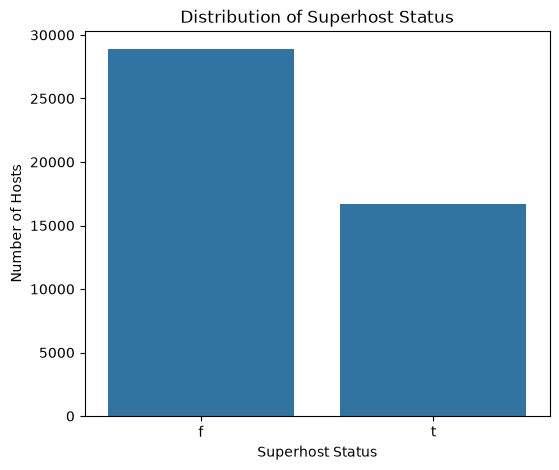

In [77]:
# Chart - 9 visualization code
plt.figure(figsize=(6,5))

sns.countplot(
    x='host_is_superhost',
    data=df,
    order=df['host_is_superhost'].value_counts().index
)

plt.title("Distribution of Superhost Status")
plt.xlabel("Superhost Status")
plt.ylabel("Number of Hosts")

plt.show()

### 1. Why did you pick the specific chart?

A bar chart was chosen because **host_is_superhost** is a categorical feature. It clearly compares the number of Superhosts and non-Superhosts, making it easy to understand the distribution of host status.

### 2. What is/are the insight(s) found from the chart?

- The majority of Airbnb hosts are **not Superhosts**, indicating that regular hosts make up the largest share of the platform.
- A considerable number of hosts have achieved **Superhost** status, although they remain fewer than non-Superhosts.
- The difference between the two groups suggests that earning Superhost status is relatively selective and represents a smaller segment of hosts.

### 3. Will the gained insights help creating a positive business impact?

Yes. Identifying the proportion of Superhosts helps Airbnb evaluate host quality across the platform. These insights can support host reward programs, improve guest recommendations by highlighting experienced hosts, and encourage regular hosts to improve their performance to achieve Superhost status, ultimately enhancing customer satisfaction.

#### Chart - 10

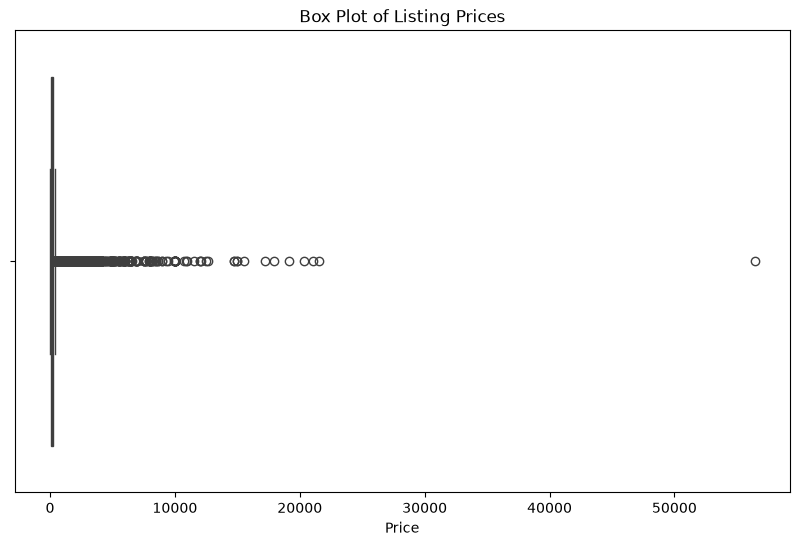

In [78]:
# Chart - 10 visualization code
plt.figure(figsize=(10,6))

sns.boxplot(x=df['price'])

plt.title("Box Plot of Listing Prices")
plt.xlabel("Price")

plt.show()

### 1. Why did you pick the specific chart?

A box plot was chosen because it effectively summarizes the distribution of the **price** feature while highlighting the presence of outliers. Since clustering algorithms are sensitive to extreme values, identifying outliers is an important preprocessing step.

### 2. What is/are the insight(s) found from the chart?

- The majority of Airbnb listings are concentrated within a relatively low price range.
- A large number of **high-priced outliers** are present, indicating that a small proportion of listings are significantly more expensive than the rest.
- An extremely expensive listing is visible, suggesting the presence of luxury or premium accommodations that differ substantially from typical listings.

### 3. Will the gained insights help creating a positive business impact?

Yes. Identifying price outliers helps Airbnb distinguish luxury listings from standard accommodations, enabling better market segmentation and pricing strategies. These insights also highlight the need for feature scaling or appropriate outlier handling before applying clustering algorithms, leading to more reliable and meaningful clusters.

#### Chart - 11

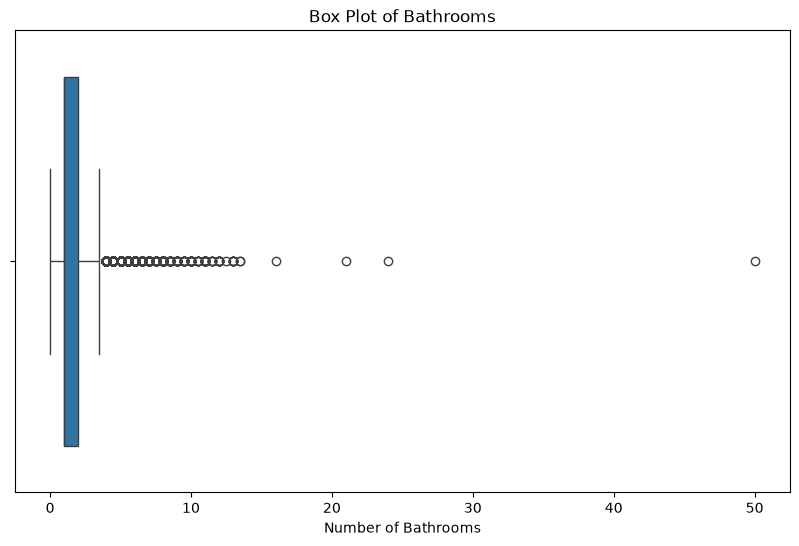

In [79]:
# Chart - 11 visualization code
plt.figure(figsize=(10,6))

sns.boxplot(x=df['bathrooms'])

plt.title("Box Plot of Bathrooms")
plt.xlabel("Number of Bathrooms")

plt.show()

### 1. Why did you pick the specific chart?

A box plot was chosen because it effectively summarizes the distribution of the **bathrooms** feature while highlighting potential outliers. This helps identify unusual property characteristics that may influence clustering results.

### 2. What is/are the insight(s) found from the chart?

- Most Airbnb listings have **1 to 2 bathrooms**, indicating that standard-sized accommodations dominate the dataset.
- Several listings have a significantly higher number of bathrooms, representing **clear outliers**.
- An extremely large outlier with **50 bathrooms** is present, suggesting the existence of luxury, commercial, or potentially anomalous listings.

### 3. Will the gained insights help creating a positive business impact?

Yes. Understanding the distribution of bathrooms helps Airbnb distinguish standard accommodations from luxury or large-capacity properties. These insights support better property segmentation, improve pricing strategies, and highlight the importance of handling outliers before clustering to produce more accurate and meaningful groups.

#### Chart - 12

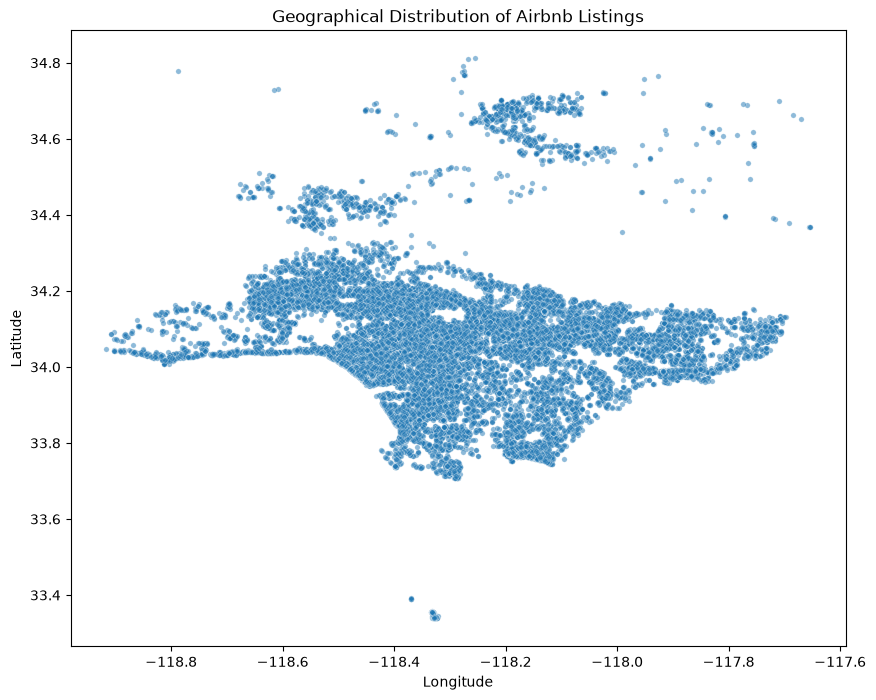

In [80]:
# Chart - 12 visualization code
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='longitude',
    y='latitude',
    data=df,
    alpha=0.5,
    s=15
)

plt.title("Geographical Distribution of Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### 1. Why did you pick the specific chart?

A scatter plot was chosen because **latitude** and **longitude** are continuous numerical variables representing the geographical location of each Airbnb listing. This visualization is ideal for identifying spatial patterns, dense regions, and potential geographic clusters.

### 2. What is/are the insight(s) found from the chart?

- Airbnb listings are **highly concentrated in specific geographic regions**, indicating that certain areas have a much higher density of properties.
- Several dense clusters are visible, while other regions contain relatively few listings, suggesting an uneven spatial distribution across the study area.
- A small number of listings are located far from the main clusters, representing geographically isolated properties.

### 3. Will the gained insights help creating a positive business impact?

Yes. The geographic distribution of listings helps Airbnb identify high-demand areas and regions with lower market penetration. These insights can improve location-based recommendations, support expansion strategies, optimize pricing across different neighborhoods, and enable more meaningful location-based clustering of properties.

#### Chart - 13

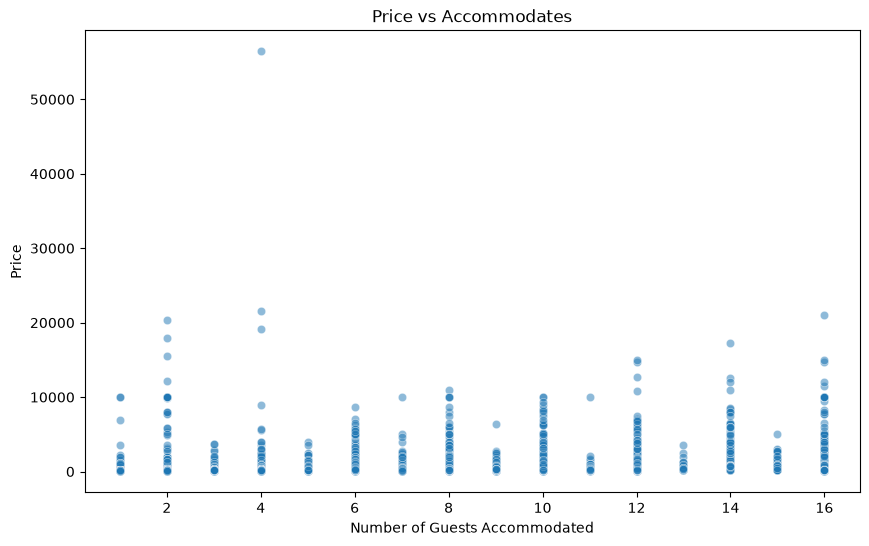

In [81]:
# Chart - 13 visualization code
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='accommodates',
    y='price',
    data=df,
    alpha=0.5
)

plt.title("Price vs Accommodates")
plt.xlabel("Number of Guests Accommodated")
plt.ylabel("Price")

plt.show()

### 1. Why did you pick the specific chart?

A scatter plot was chosen because both **price** and **accommodates** are numerical variables. It is an effective visualization for examining the relationship between guest capacity and listing price while identifying trends, variability, and outliers.

### 2. What is/are the insight(s) found from the chart?

- There is a **general positive relationship** between guest capacity and listing price, as properties accommodating more guests tend to have higher prices.
- Considerable variation in prices exists for the same guest capacity, indicating that factors such as location, amenities, and property type also influence pricing.
- Several **extreme price outliers** are visible across different accommodation capacities, suggesting the presence of luxury or premium listings.

### 3. Will the gained insights help creating a positive business impact?

Yes. Understanding the relationship between guest capacity and price helps Airbnb evaluate pricing consistency across different property sizes. These insights can support dynamic pricing strategies, improve property recommendations, and enable more meaningful clustering by combining capacity with pricing characteristics.

#### Chart - 14 - Correlation Heatmap

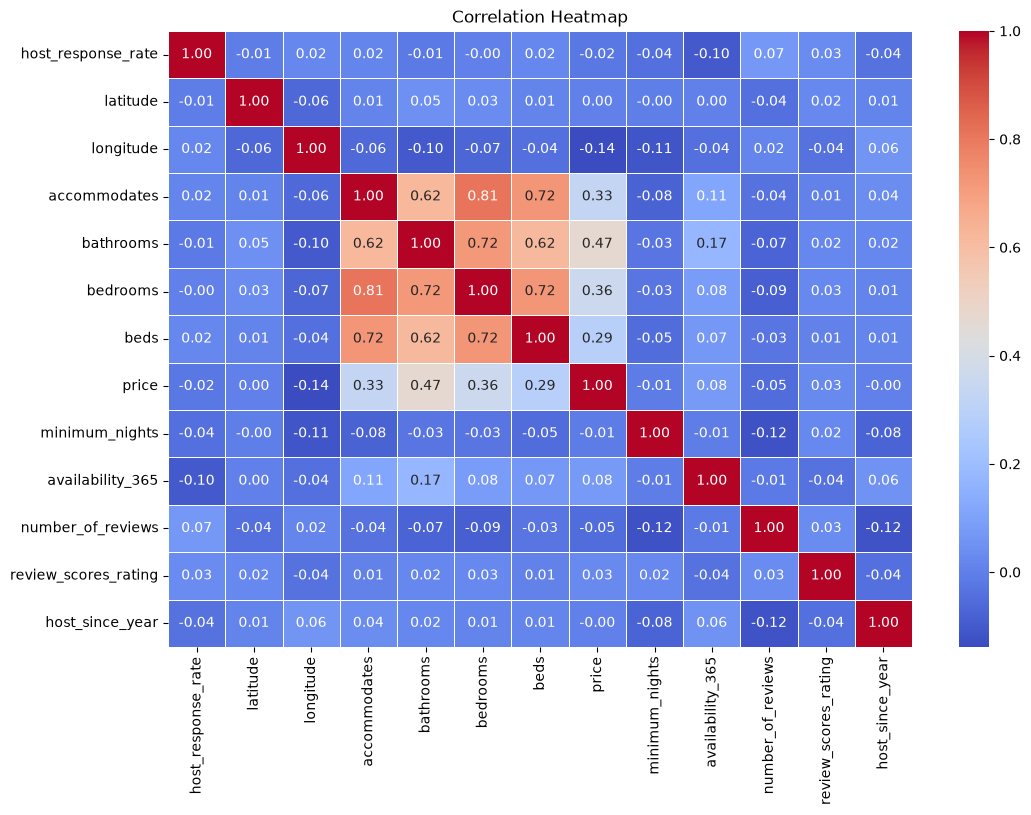

In [82]:
# Correlation Heatmap visualization code
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### 1. Why did you pick the specific chart?

A correlation heatmap was chosen because it provides a comprehensive view of the relationships between numerical variables. It helps identify highly correlated features, detect redundancy, and support feature selection before applying clustering algorithms.

### 2. What is/are the insight(s) found from the chart?

- **Accommodates** and **bedrooms** show a strong positive correlation (**0.81**), indicating that properties accommodating more guests generally have more bedrooms.
- **Bathrooms**, **beds**, and **bedrooms** also exhibit strong positive correlations (approximately **0.62–0.72**), suggesting these features increase together as property size increases.
- **Price** has a moderate positive correlation with **bathrooms (0.47)**, **bedrooms (0.36)**, and **accommodates (0.33)**, indicating that larger properties tend to be more expensive.
- Most of the remaining variables have **weak or negligible correlations**, suggesting they provide unique information and are unlikely to be redundant.

### 3. Will the gained insights help creating a positive business impact?

Yes. Understanding feature correlations helps identify the characteristics that define different types of Airbnb listings. These insights improve feature selection, reduce redundancy, and enhance clustering performance, allowing Airbnb to create more meaningful property segments for pricing, recommendations, and business analysis.

#### Chart - 15 - Pair Plot

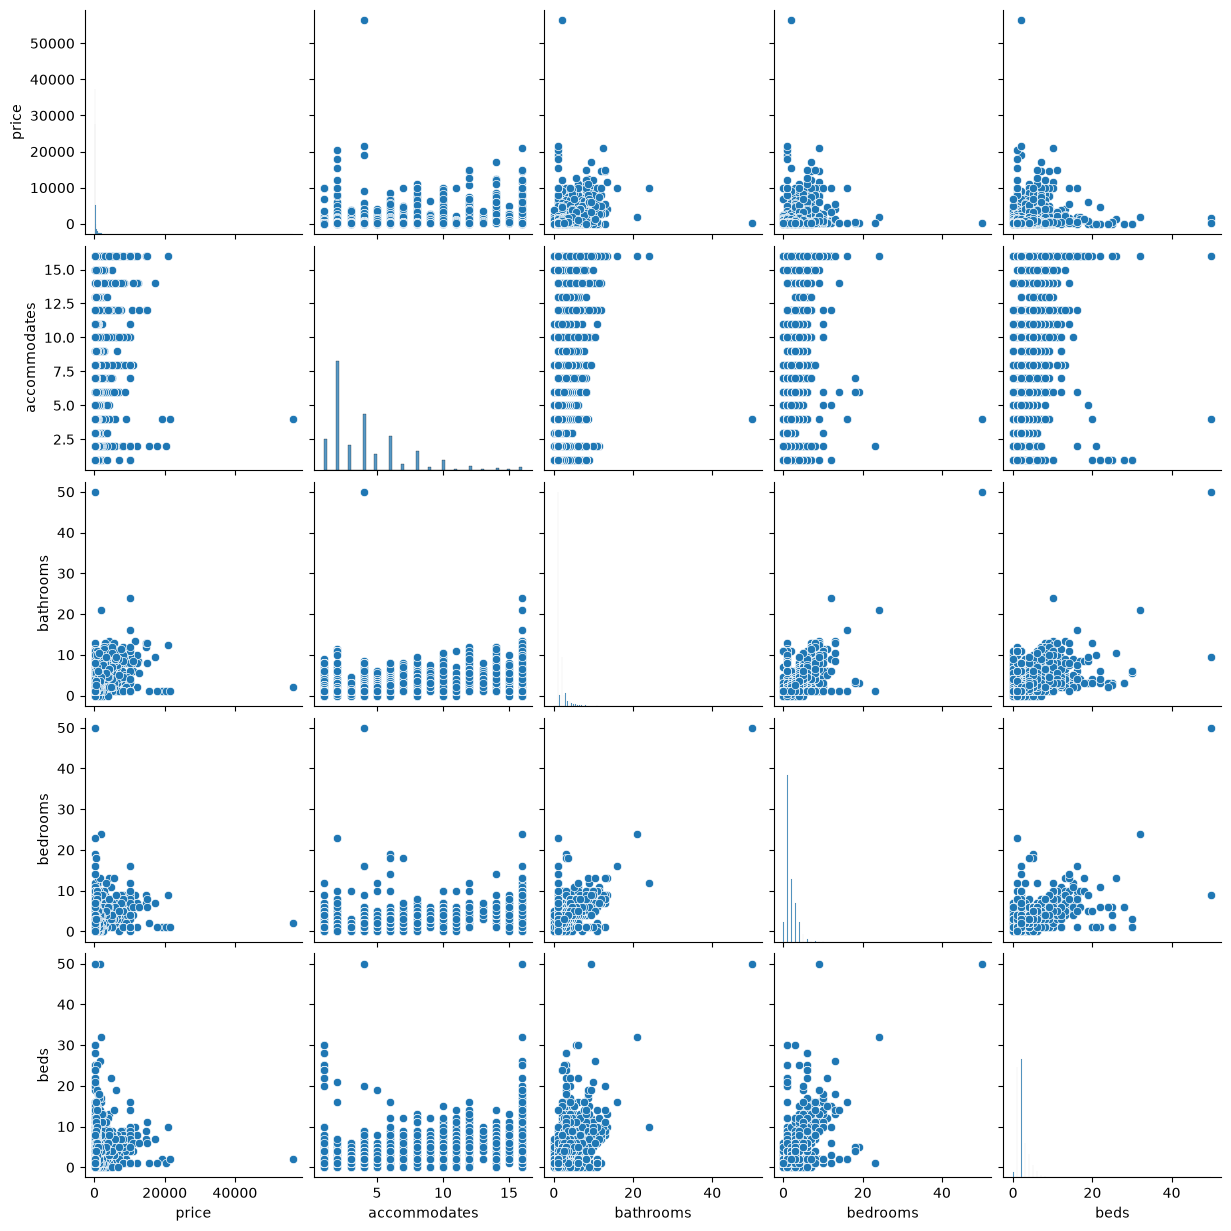

In [83]:
# Pair Plot visualization code
selected_features = [
    'price',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds'
]

sns.pairplot(
    df[selected_features],
    diag_kind='hist'
)

plt.show()

### 1. Why did you pick the specific chart?

A pair plot was chosen because it simultaneously visualizes the distributions of multiple numerical variables and their pairwise relationships. It helps identify trends, correlations, potential clusters, and outliers before applying clustering algorithms.

### 2. What is/are the insight(s) found from the chart?

- **Bathrooms, bedrooms, beds, and accommodates** show clear positive relationships, indicating that larger properties generally have more rooms, beds, and guest capacity.
- **Price** tends to increase with property size, although considerable variation exists, suggesting that other factors such as location and amenities also influence pricing.
- The diagonal plots indicate that most numerical features are **right-skewed**, with the majority of listings concentrated at lower values.
- Several **extreme outliers** are visible across variables such as price, bathrooms, bedrooms, and beds, representing luxury or unusually large properties.

### 3. Will the gained insights help creating a positive business impact?

Yes. The pair plot provides a comprehensive understanding of how important property characteristics interact with one another. These insights support better feature selection, improve clustering performance, and help Airbnb identify meaningful property segments for pricing strategies, personalized recommendations, and market analysis.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [44]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [45]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [46]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [47]:
# Expand Contraction

#### 2. Lower Casing

In [48]:
# Lower Casing

#### 3. Removing Punctuations

In [49]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [50]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [51]:
# Remove Stopwords

In [52]:
# Remove White spaces

#### 6. Rephrase Text

In [53]:
# Rephrase Text

#### 7. Tokenization

In [54]:
# Tokenization

#### 8. Text Normalization

In [55]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [56]:
# POS Taging

#### 10. Text Vectorization

In [57]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [58]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [59]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [60]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [61]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [62]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [63]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [64]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [65]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [66]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [67]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [68]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [69]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***